# Initial Data Exploration

## 1. Goal
- Understand dataset structure
- Identify data quality issues
- Discover initial patterns and insights

## 2. Import

In [2]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns

## 3. Load Dataset
Load the dataset and inspect the first few rows to verify that the data was loaded correctly.

In [3]:
df = pd.read_csv("../data/raw/postings.csv")
df.head()

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


## 4. Dataset Overview
Get a high-level understanding of the dataset's shape, column types, and summary statistics before diving into individual features.

### 4.1 Shape & Structure

In [4]:
df.shape

(123849, 31)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  str    
 2   title                       123849 non-null  str    
 3   description                 123842 non-null  str    
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   str    
 6   location                    123849 non-null  str    
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  str    
 12  applies                     23320 non-null   float64
 13  original_listed_time     

**Observations:**
- Dataset contains 123,849 rows and 31 columns.
- Both numerical and categorical features are present.
- Several columns contain missing values.
- Some columns may require datatype conversion.

### 4.2 Data Types

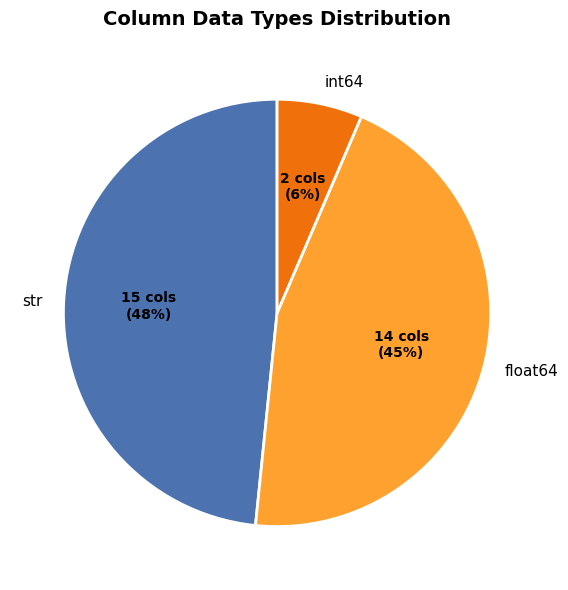

In [6]:

dtype_counts = df.dtypes.map(lambda x: str(x)).value_counts()
 
fig, ax = plt.subplots(figsize=(6, 6))
colors = ['#4C72B0', '#FFA12F', "#F0710C"]
wedges, texts, autotexts = ax.pie(
    dtype_counts.values,
    labels=dtype_counts.index,
    autopct=lambda pct: f'{int(round(pct / 100 * sum(dtype_counts.values)))} cols\n({pct:.0f}%)',
    colors=colors[:len(dtype_counts)],
    startangle=90,
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax.set_title('Column Data Types Distribution', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
 

### 4.3 Numeric Features

In [7]:
df.describe()

,job_id,max_salary,company_id,views,med_salary,min_salary,applies,original_listed_time,remote_allowed,expiry,closed_time,listed_time,sponsored,normalized_salary,zip_code,fips
count,1.238490e+05,2.979300e+04,1.221320e+05,122160.000000,6280.000000,2.979300e+04,23320.000000,1.238490e+05,15246.0,1.238490e+05,1.073000e+03,1.238490e+05,123849.0,3.607300e+04,102977.000000,96434.000000
mean,3.896402e+09,9.193942e+04,1.220401e+07,14.618247,22015.619876,6.491085e+04,10.591981,1.713152e+12,1.0,1.716213e+12,1.712928e+12,1.713204e+12,0.0,2.053270e+05,50400.491887,28713.879887
std,8.404355e+07,7.011101e+05,2.554143e+07,85.903598,52255.873846,4.959738e+05,29.047395,4.848209e+08,0.0,2.321394e+09,3.622893e+08,3.989122e+08,0.0,5.097627e+06,30252.232515,16015.929825
min,9.217160e+05,1.000000e+00,1.009000e+03,1.000000,0.000000,1.000000e+00,1.000000,1.701811e+12,1.0,1.712903e+12,1.712346e+12,1.711317e+12,0.0,0.000000e+00,1001.000000,1003.000000
25%,3.894587e+09,4.828000e+01,1.435200e+04,3.000000,18.940000,3.700000e+01,1.000000,1.712863e+12,1.0,1.715481e+12,1.712670e+12,1.712886e+12,0.0,5.200000e+04,24112.000000,13121.000000
50%,3.901998e+09,8.000000e+04,2.269650e+05,4.000000,25.500000,6.000000e+04,3.000000,1.713395e+12,1.0,1.716042e+12,1.712670e+12,1.713408e+12,0.0,8.150000e+04,48059.000000,29183.000000
75%,3.904707e+09,1.400000e+05,8.047188e+06,8.000000,2510.500000,1.000000e+05,8.000000,1.713478e+12,1.0,1.716088e+12,1.713283e+12,1.713484e+12,0.0,1.250000e+05,78201.000000,42077.000000
max,3.906267e+09,1.200000e+08,1.034730e+08,9975.000000,750000.000000,8.500000e+07,967.000000,1.713573e+12,1.0,1.729125e+12,1.713562e+12,1.713573e+12,0.0,5.356000e+08,99901.000000,56045.000000


In [8]:
print(f"Numeric columns: {df.select_dtypes(include='number').shape[1]}")

Numeric columns: 16


**Observations:**
- Dataset has 16 numeric columns, but many are IDs or timestamps rather than true numeric features.
- Salary columns (`max_salary`, `min_salary`, `med_salary`, `normalized_salary`) and engagement metrics (`views`, `applies`) are the main numeric features of interest.
- `sponsored` and `remote_allowed` have zero variance - can likely be dropped.
- Timestamp columns are stored as epoch milliseconds - will need conversion.

### 4.4 Non-numerical Features

In [9]:
df.describe(include=['object','string'])

,company_name,title,description,pay_period,location,formatted_work_type,job_posting_url,application_url,application_type,formatted_experience_level,skills_desc,posting_domain,work_type,currency,compensation_type
count,122130,123849,123842,36073,123849,123849,123849,87184,123849,94440,2439,83881,123849,36073,36073
unique,24428,72521,107827,5,8526,7,123849,84800,4,6,2212,4443,7,6,1
top,Liberty Healthcare and Rehabilitation Services,Sales Manager,Position Summary: Our Sales Manager has managi...,YEARLY,United States,Full-time,https://www.linkedin.com/jobs/view/921716/?trk...,https://app.dataannotation.tech/worker_signup?...,OffsiteApply,Mid-Senior level,This position requires the following skills: E...,www.click2apply.net,FULL_TIME,USD,BASE_SALARY
freq,1108,673,474,20628,8125,98814,1,205,84607,41489,28,3811,98814,36058,36073


In [10]:
print(f"Non-numeric columns: {df.select_dtypes(include=['object','string']).shape[1]}")

Non-numeric columns: 15


**Observations:**
- 15 categorical columns with varying cardinality.
- `title` and `description` are high-cardinality free-text fields (72k and 108k unique values).
- `compensation_type` has only 1 unique value - can likely be dropped.

## 5. Missing Values
Assess the extent and structure of missing data across all columns - distinguishing between random gaps and systematic patterns tied to the data source.

### 5.1 Missingness Patterns
Visualize the overall pattern of missing values and how the missingness of different features correlates.

<Axes: >

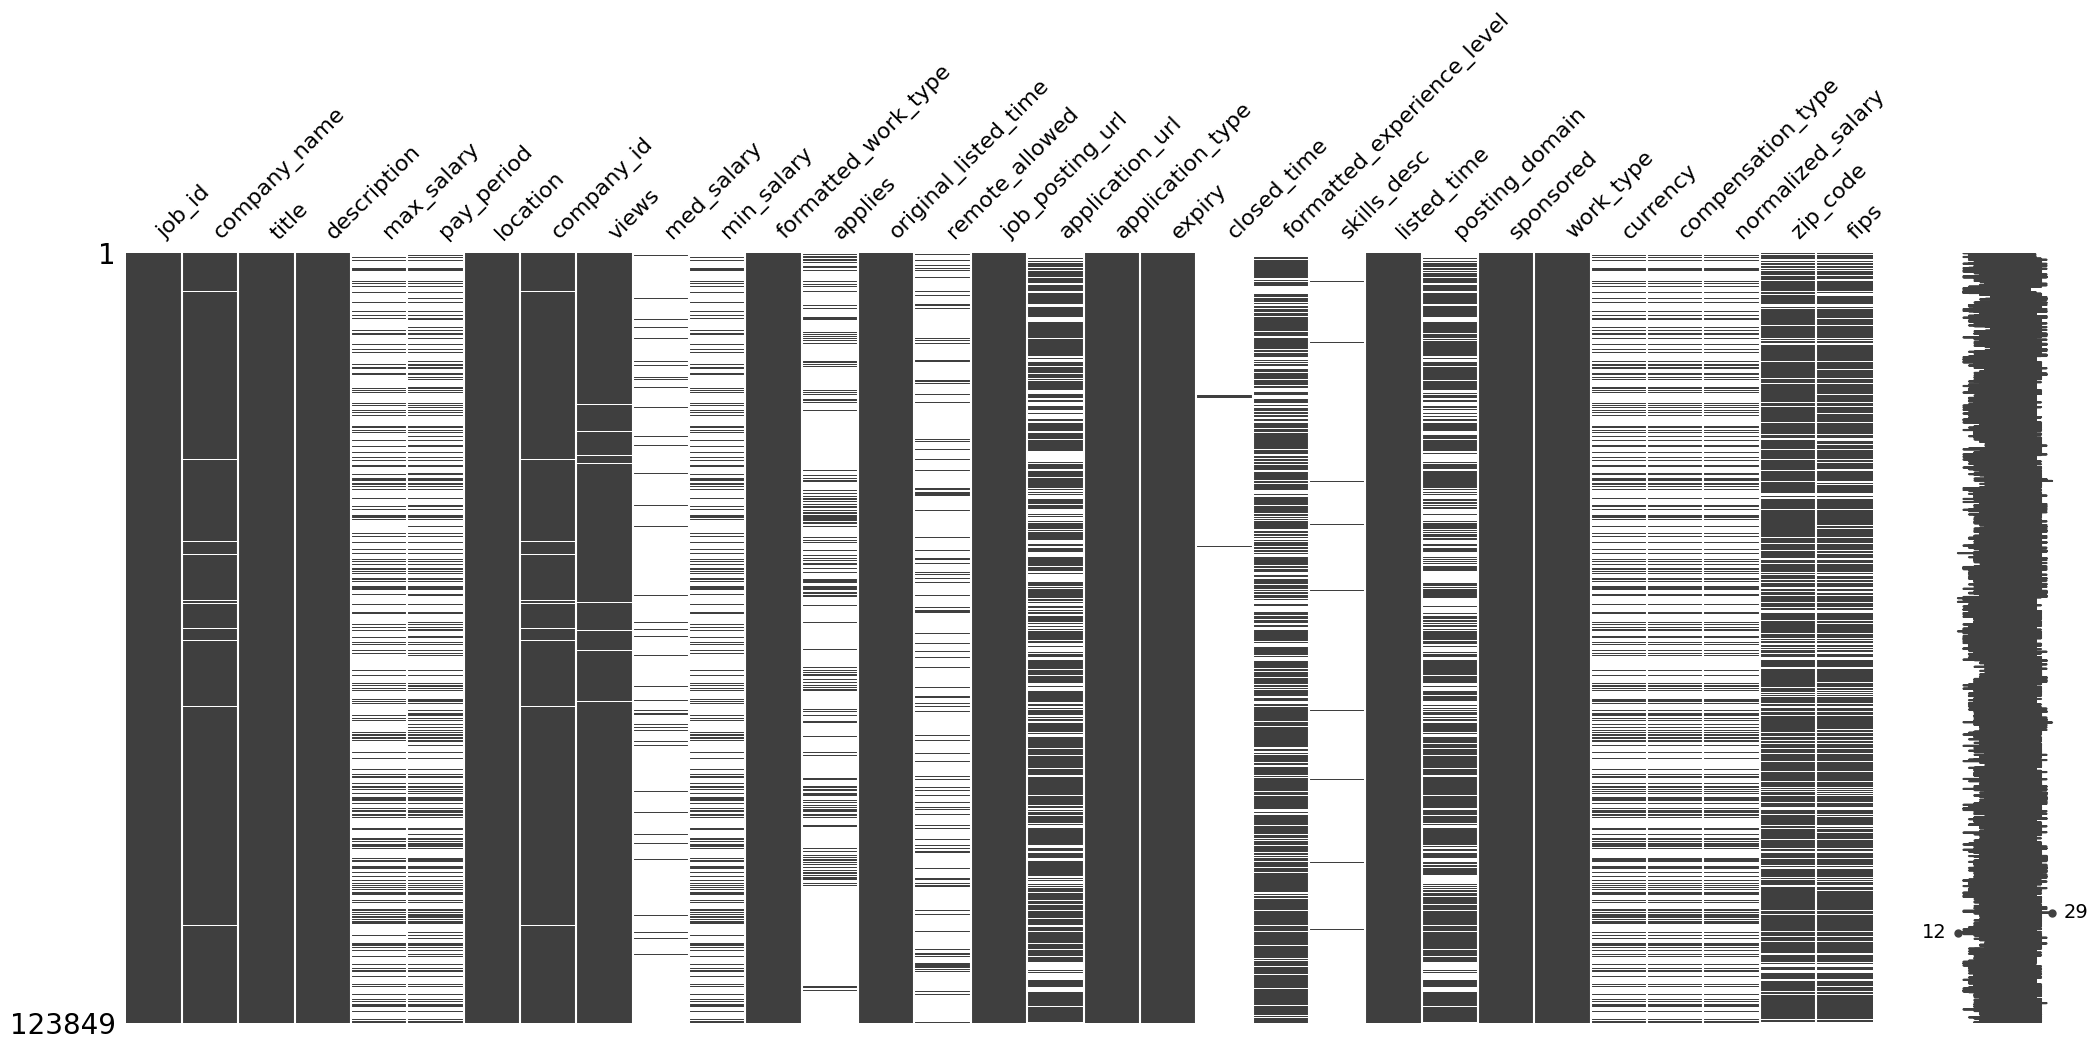

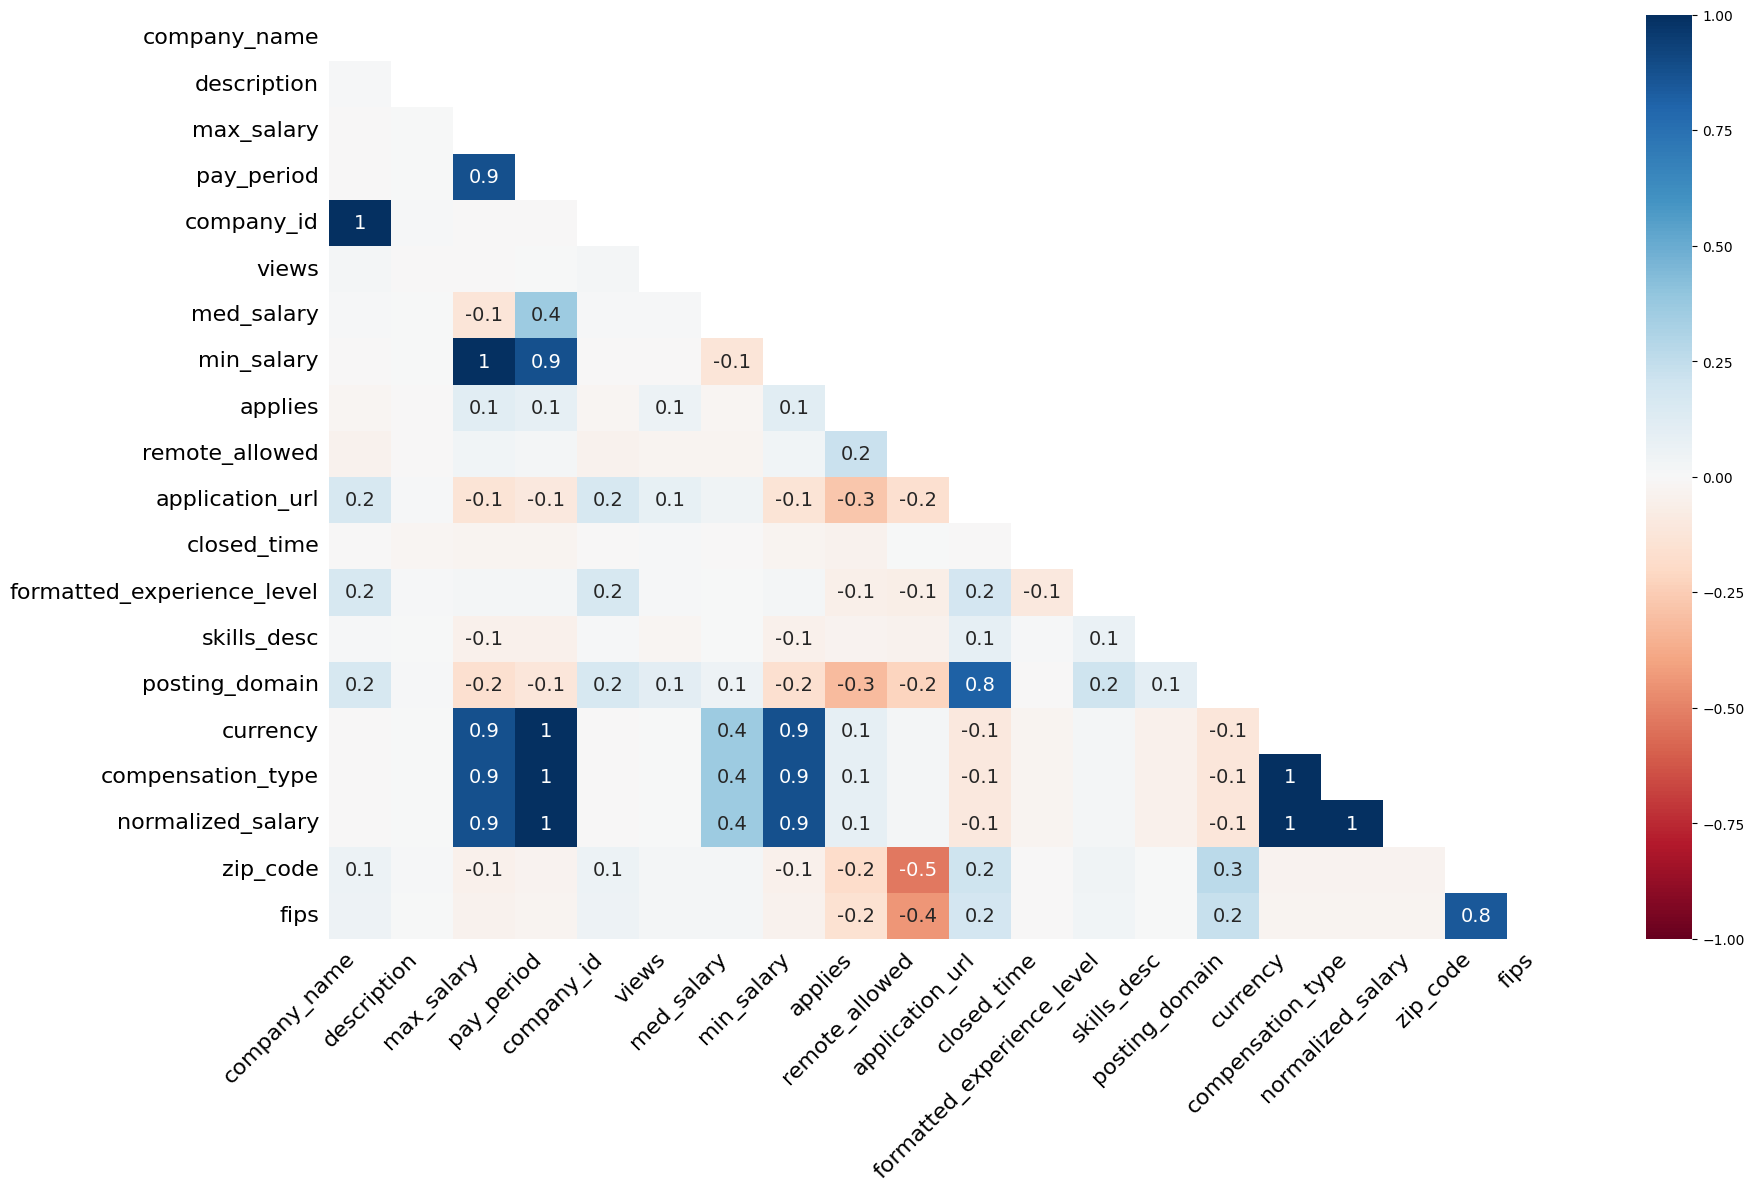

In [11]:
msno.matrix(df)

msno.heatmap(df)

**Observations:**

The heatmap shows how the missingness of one feature correlates with the missingness of another. Since this dataset originates from LinkedIn job postings, many patterns reflect optional input fields rather than data corruption.

**Strongly co-missing feature groups (positive correlations):**
- **Salary fields** (`med_salary`, `min_salary`, `max_salary`, `normalized_salary`, `currency`, `compensation_type`, `pay_period`) form a tightly co-missing block (r ≈ 0.9–1.0). These are missing as a unit, not independently.
- **`zip_code` and `fips`** (r = 0.8) - geographic identifiers are missing together.
- **`posting_domain` and `application_url`** (r = 0.8) - external application metadata is either present or absent as a pair.

**Notable negative missingness correlations:**
- **`zip_code` vs `remote_allowed`** (r = −0.5) and **`fips` vs `remote_allowed`** (r = −0.4). Remote postings have less reason to include a physical location, so geographic data is intentionally omitted.
- **`application_url` / `posting_domain` vs `applies`** (r = −0.3). Postings using Easy Apply track in-platform counts, while those redirecting to an external URL don't capture this metric.

**Implications:** The missingness is largely not random - it is driven by employer choices and platform structure. Salary fields can be treated as a single block. Geographic fields are structurally absent for remote roles (imputation would be inappropriate). The inverse `applies` / `application_url` relationship reflects a real platform mechanic, not a data quality issue.

### 5.2 Missing Values by Column
Quantify the percentage of missing values per column and classify them by severity.

In [12]:
df.isna().sum().sort_values()

job_id                             0
title                              0
location                           0
formatted_work_type                0
original_listed_time               0
job_posting_url                    0
expiry                             0
application_type                   0
sponsored                          0
listed_time                        0
work_type                          0
description                        7
views                           1689
company_id                      1717
company_name                    1719
zip_code                       20872
fips                           27415
formatted_experience_level     29409
application_url                36665
posting_domain                 39968
normalized_salary              87776
pay_period                     87776
compensation_type              87776
currency                       87776
max_salary                     94056
min_salary                     94056
applies                       100529
r

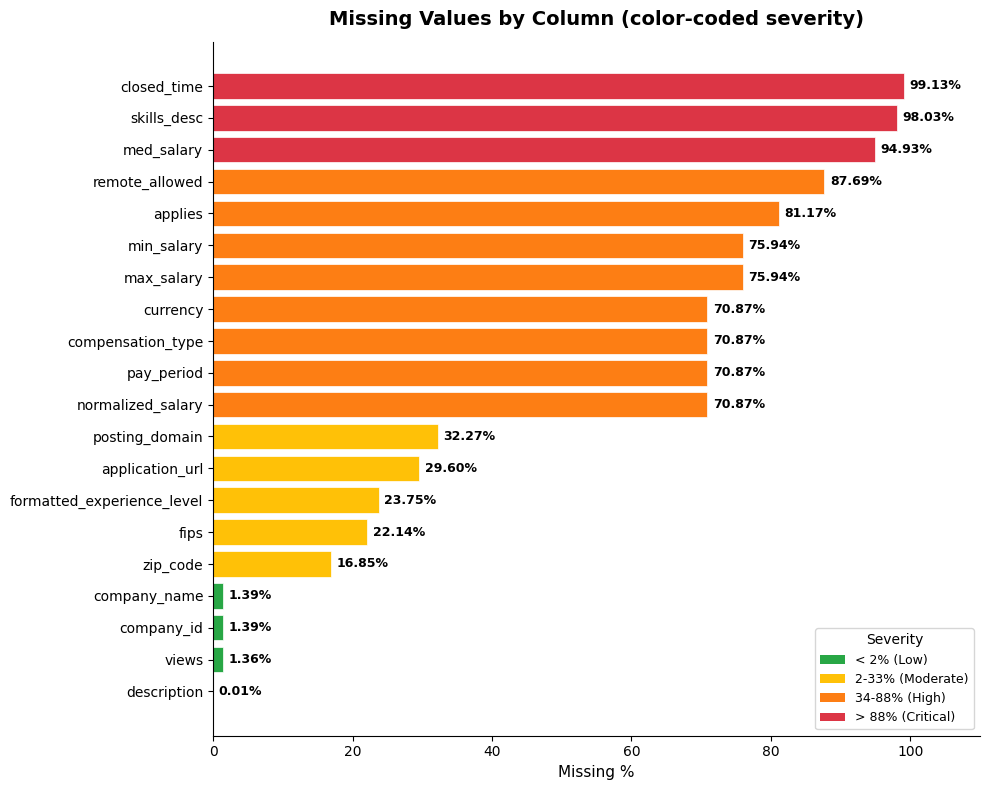

In [13]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]  # only columns with missing values

def severity_color(pct):
    if pct < 2:
        return '#28a745'   # green
    elif pct < 33:
        return '#ffc107'   # yellow
    elif pct < 88:
        return '#fd7e14'   # orange
    else:
        return '#dc3545'   # red

colors = [severity_color(p) for p in missing_pct.values]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(missing_pct.index, missing_pct.values, color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%', va='center', fontsize=9, fontweight='bold')

legend_items = [
    Patch(facecolor='#28a745', label='< 2% (Low)'),
    Patch(facecolor='#ffc107', label='2-33% (Moderate)'),
    Patch(facecolor='#fd7e14', label='34-88% (High)'),
    Patch(facecolor='#dc3545', label='> 88% (Critical)')
]
ax.legend(handles=legend_items, loc='lower right', fontsize=9, title='Severity', title_fontsize=10)

ax.set_xlabel('Missing %', fontsize=11)
ax.set_title('Missing Values by Column (color-coded severity)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlim(0, 110)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Observations:**
- **Mostly complete (< 2% missing):** `company_name`, `company_id`, `views`, `description` - reliably populated.
- **Moderately missing (16–33%):** `zip_code`, `fips`, `formatted_experience_level`, `application_url`, `posting_domain`.
- **Heavily missing (70–88%):** `max_salary`, `min_salary`, `pay_period`, `applies`, `currency`, `compensation_type`, `normalized_salary`, `remote_allowed`. The salary-related columns all share similar missingness (~71–76%), confirming they are linked.
- **Nearly empty (94–99%):** `med_salary` (95%), `skills_desc` (98%), `closed_time` (99%) - too sparse to be useful as-is.

## 6. Duplicate Analysis
Investigate different layers of duplication in the dataset - from fully identical rows to near-duplicates that may represent reposted job listings.

### 6.1 Exact Duplicates

In [14]:
print(f"Fully duplicate rows (all columns): {df.duplicated().sum()}")
print(f"Duplicate job_id values:            {df.duplicated(subset='job_id').sum()}")

Fully duplicate rows (all columns): 0
Duplicate job_id values:            0


**Observations:**
- **0** fully duplicate rows - no two rows are byte-for-byte identical across all 31 columns.
- **0** duplicate `job_id` values - each row maps to a unique job posting identifier.

However, `job_id` and `job_posting_url` are always unique by design (every URL is distinct, every ID is distinct). Removing these identifiers lets us check whether the *content* of two postings is actually the same.

### 6.2 Content-Level Duplicates (ignoring identifiers)

In [15]:
df_content = df.drop(columns=['job_id', 'job_posting_url'])
content_dupes = df_content.duplicated().sum()
print(f"Duplicates after dropping job_id & job_posting_url: {content_dupes}")

Duplicates after dropping job_id & job_posting_url: 52


**Observations:**
- Dropping `job_id` and `job_posting_url` surfaces **52 content-identical rows** - these are true duplicates that simply received a different ID/URL.
- A small number, but confirms that identifier uniqueness alone does not guarantee content uniqueness.

### 6.3 Near-Duplicates / Potential Reposts (ignoring time & engagement columns)
Job postings are often reposted - same role, same company, same description - but with refreshed timestamps, new view/apply counts, and a different application URL. Dropping these *volatile* columns reveals how many postings share identical core content.

In [16]:
volatile_cols = ['original_listed_time', 'expiry', 'sponsored', 'listed_time',
                 'views', 'applies', 'closed_time', 'application_url', 'application_type']

df_core = df_content.drop_duplicates()  # remove the 52 exact content dupes first
repost_dupes = df_core.drop(columns=volatile_cols).duplicated().sum()
print(f"Near-duplicate (potential repost) rows: {repost_dupes}")

Near-duplicate (potential repost) rows: 4027


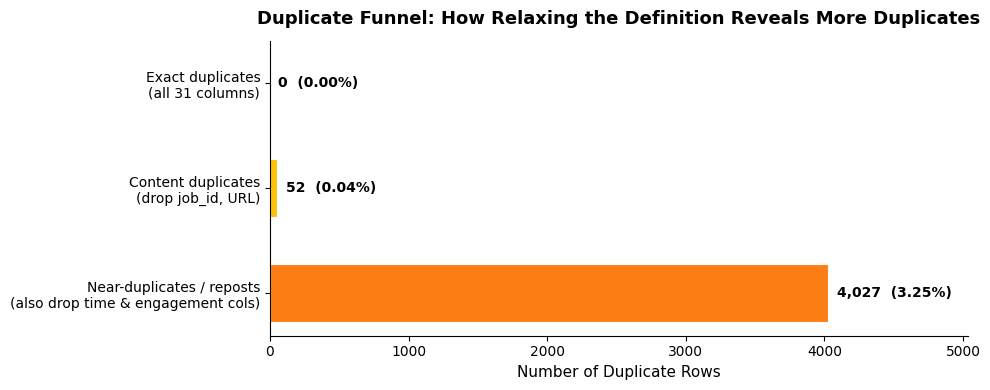

In [17]:
labels = [
    'Exact duplicates\n(all 31 columns)',
    'Content duplicates\n(drop job_id, URL)',
    'Near-duplicates / reposts\n(also drop time & engagement cols)'
]
values = [0, content_dupes, repost_dupes]  # 0, 52, 4027
colors = ['#28a745', '#ffc107', '#fd7e14']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(labels, values, color=colors, edgecolor='white', linewidth=0.8, height=0.55)

for bar, val in zip(bars, values):
    x_pos = val + max(values) * 0.015 if val > 0 else max(values) * 0.015
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f'{val:,}  ({val/len(df)*100:.2f}%)',
            va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Number of Duplicate Rows', fontsize=11)
ax.set_title('Duplicate Funnel: How Relaxing the Definition Reveals More Duplicates',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, max(values) * 1.25)
ax.spines[['top', 'right']].set_visible(False)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Observations:**
- At the strictest level (all 31 columns), the dataset appears clean with **0** duplicates.
- Removing the two always-unique identifier columns (`job_id`, `job_posting_url`) surfaces **52 content-identical rows** - these are true duplicates that simply received a different ID/URL.
- The biggest jump comes at the repost level: **~4,027 rows** (~3.25% of the dataset) share identical core content (title, company, description, salary, location, etc.) and differ only in timestamps, engagement metrics, and application links - a strong signal of job reposting.

> **Note:** Dropping columns here is an *analytical technique* to detect duplication patterns. It does **not** imply these columns should be dropped during data cleaning - that decision depends on the downstream problem and modelling goals.

### 6.4 Same-Position Clusters (same title + company + description)
Section 6.3 compared all core content columns. Here we relax the match to just three fields - `title`, `company_name`, and `description` - to capture postings for the **same position** that may differ in location, salary, or other metadata (e.g. a company posting the same role in multiple cities).

In [18]:
same_pos_cols = ['title', 'company_name', 'description']
same_pos = df.dropna(subset=same_pos_cols).groupby(same_pos_cols).size().reset_index(name='count')
same_pos_multi = same_pos[same_pos['count'] > 1].sort_values('count', ascending=False)

print(f"Same-position clusters (same title + company + description): {len(same_pos_multi)}")
print(f"Total rows in same-position clusters: {same_pos_multi['count'].sum():,}")

Same-position clusters (same title + company + description): 5002
Total rows in same-position clusters: 17,635


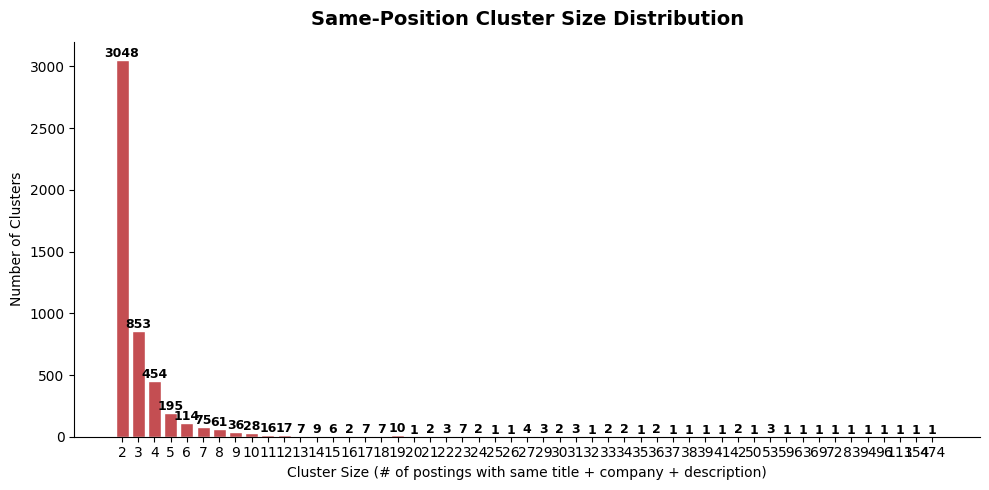

In [19]:
cluster_sizes = same_pos_multi['count'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cluster_sizes.index.astype(str), cluster_sizes.values,
              color='#C44E52', edgecolor='white')
ax.bar_label(bars, fontsize=9, fontweight='bold')
ax.set_xlabel('Cluster Size (# of postings with same title + company + description)', fontsize=10)
ax.set_ylabel('Number of Clusters', fontsize=10)
ax.set_title('Same-Position Cluster Size Distribution',
             fontsize=14, fontweight='bold', pad=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Observations:**
- Grouping by just `title` + `company` + `description` (ignoring location) captures both true reposts and multi-location postings for the same role.
- The distribution is heavily right-skewed: most clusters have only 2–3 postings, but a long tail of large clusters exists - likely companies posting the same role across many cities.
- This is a broader duplicate signal than section 6.3 and will be useful for deciding on a deduplication strategy.

## 7. Feature Distributions


Columns identified as constant (`sponsored`, `remote_allowed`, `compensation_type`) or unique identifiers (`job_id`, `job_posting_url`) are excluded - they carry no distributional information (see sections 4.3, 4.4, 6.1).

### 7.1 Numeric Features

#### 7.1.1 Salary (`normalized_salary`)

The `normalized_salary` column is the annualized salary figure. We show the full distribution first, then cap at the 99th percentile to focus on the bulk of the data without outlier compression.

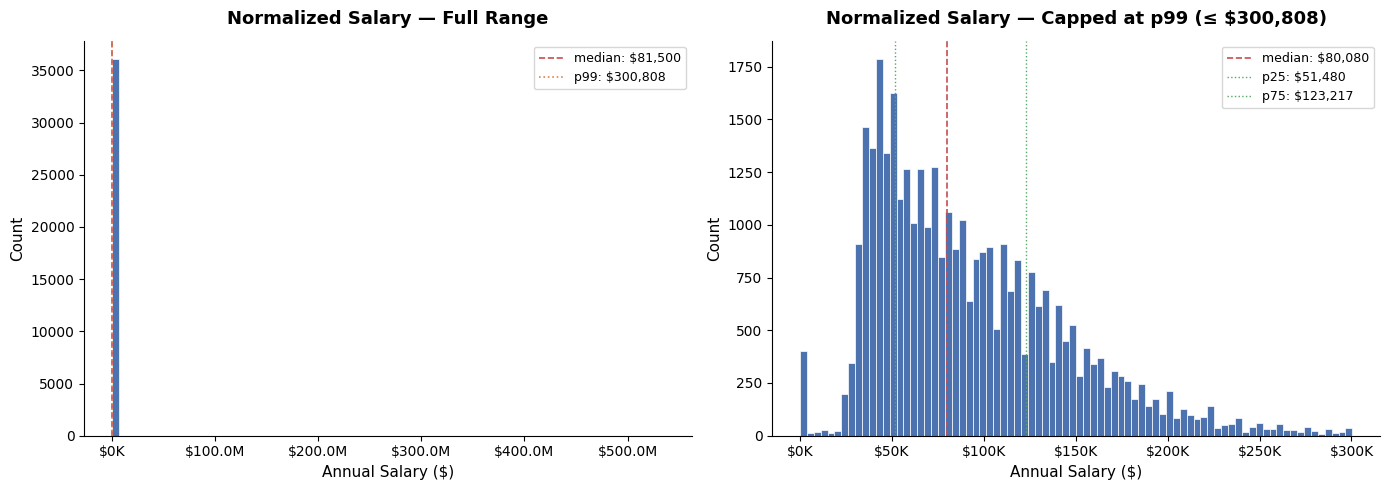

Total non-null: 36,073
Rows above p99 (>300,808): 361 (1.00%)
Min: $0  |  Max: $535,600,000
Median: $81,500  |  IQR: $52,000 – $125,000


In [20]:
salary = df['normalized_salary'].dropna()

p99 = salary.quantile(0.99)
salary_capped = salary[salary <= p99]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left: full distribution ---
axes[0].hist(salary, bins=80, color='#4C72B0', edgecolor='white', linewidth=0.5)
axes[0].axvline(salary.median(), color='#C44E52', linestyle='--', linewidth=1.2, label=f'median: ${salary.median():,.0f}')
axes[0].axvline(p99, color='#DD8452', linestyle=':', linewidth=1.2, label=f'p99: ${p99:,.0f}')
axes[0].set_title('Normalized Salary — Full Range', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Annual Salary ($)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
axes[0].legend(fontsize=9)
axes[0].spines[['top', 'right']].set_visible(False)

# --- right: capped at p99 ---
axes[1].hist(salary_capped, bins=80, color='#4C72B0', edgecolor='white', linewidth=0.5)
axes[1].axvline(salary_capped.median(), color='#C44E52', linestyle='--', linewidth=1.2, label=f'median: ${salary_capped.median():,.0f}')
axes[1].axvline(salary_capped.quantile(0.25), color='#55A868', linestyle=':', linewidth=1, label=f'p25: ${salary_capped.quantile(0.25):,.0f}')
axes[1].axvline(salary_capped.quantile(0.75), color='#55A868', linestyle=':', linewidth=1, label=f'p75: ${salary_capped.quantile(0.75):,.0f}')
axes[1].set_title(f'Normalized Salary — Capped at p99 (≤ ${p99:,.0f})', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Annual Salary ($)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()
print(f"Total non-null: {len(salary):,}")
print(f"Rows above p99 (>{p99:,.0f}): {(salary > p99).sum():,} ({(salary > p99).mean()*100:.2f}%)")
print(f"Min: ${salary.min():,.0f}  |  Max: ${salary.max():,.0f}")
print(f"Median: ${salary.median():,.0f}  |  IQR: ${salary.quantile(0.25):,.0f} – ${salary.quantile(0.75):,.0f}")

Extreme outliers (up to $535.6M) compress the full distribution into a single bar — these are likely data entry errors and will be removed during cleaning; the capped view reveals a right-skewed but reasonable salary distribution (median ~$80K, IQR $51K–$123K) with a spike near $0 that likely reflects internships or unpaid positions.

#### 7.1.2 Engagement Metrics (`views`, `applies`)

Both `views` and `applies` are heavily right-skewed. Log-transforming reveals the underlying shape of the bulk distribution.

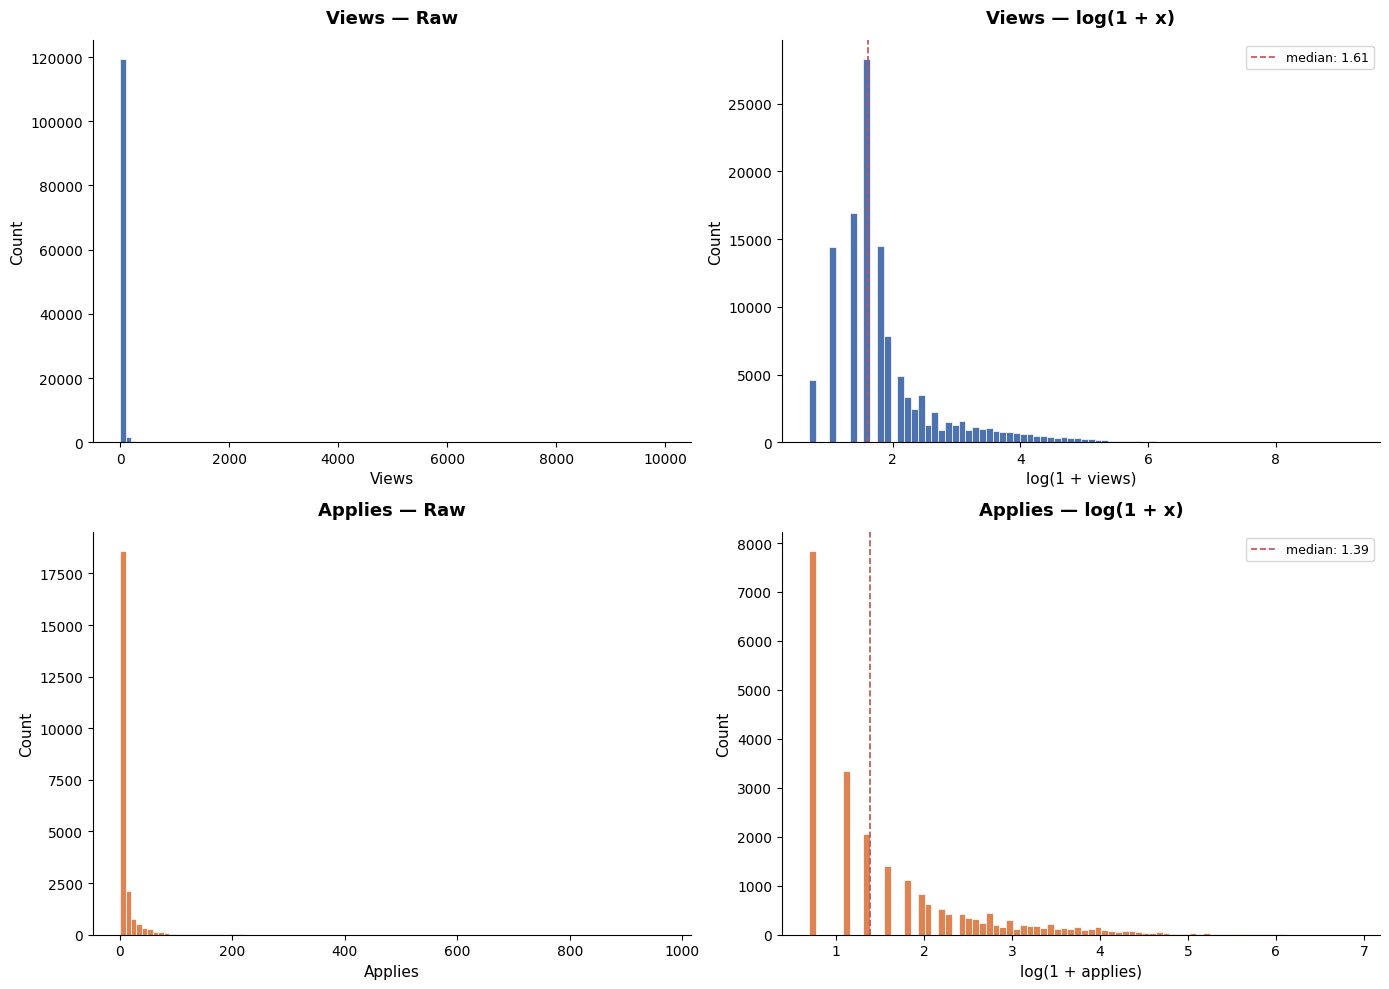

Views  — non-null: 122,160  |  median: 4  |  mean: 14.6  |  max: 9,975
Applies — non-null: 23,320  |  median: 3  |  mean: 10.6  |  max: 967


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---- views ----
views = df['views'].dropna()

axes[0, 0].hist(views, bins=100, color='#4C72B0', edgecolor='white', linewidth=0.5)
axes[0, 0].set_title('Views — Raw', fontsize=13, fontweight='bold', pad=12)
axes[0, 0].set_xlabel('Views', fontsize=11)
axes[0, 0].set_ylabel('Count', fontsize=11)
axes[0, 0].spines[['top', 'right']].set_visible(False)

views_log = np.log1p(views)
axes[0, 1].hist(views_log, bins=80, color='#4C72B0', edgecolor='white', linewidth=0.5)
axes[0, 1].axvline(views_log.median(), color='#C44E52', linestyle='--', linewidth=1.2, label=f'median: {views_log.median():.2f}')
axes[0, 1].set_title('Views — log(1 + x)', fontsize=13, fontweight='bold', pad=12)
axes[0, 1].set_xlabel('log(1 + views)', fontsize=11)
axes[0, 1].set_ylabel('Count', fontsize=11)
axes[0, 1].legend(fontsize=9)
axes[0, 1].spines[['top', 'right']].set_visible(False)

# ---- applies ----
applies = df['applies'].dropna()

axes[1, 0].hist(applies, bins=100, color='#DD8452', edgecolor='white', linewidth=0.5)
axes[1, 0].set_title('Applies — Raw', fontsize=13, fontweight='bold', pad=12)
axes[1, 0].set_xlabel('Applies', fontsize=11)
axes[1, 0].set_ylabel('Count', fontsize=11)
axes[1, 0].spines[['top', 'right']].set_visible(False)

applies_log = np.log1p(applies)
axes[1, 1].hist(applies_log, bins=80, color='#DD8452', edgecolor='white', linewidth=0.5)
axes[1, 1].axvline(applies_log.median(), color='#C44E52', linestyle='--', linewidth=1.2, label=f'median: {applies_log.median():.2f}')
axes[1, 1].set_title('Applies — log(1 + x)', fontsize=13, fontweight='bold', pad=12)
axes[1, 1].set_xlabel('log(1 + applies)', fontsize=11)
axes[1, 1].set_ylabel('Count', fontsize=11)
axes[1, 1].legend(fontsize=9)
axes[1, 1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Views  — non-null: {len(views):,}  |  median: {views.median():.0f}  |  mean: {views.mean():.1f}  |  max: {views.max():,.0f}")
print(f"Applies — non-null: {len(applies):,}  |  median: {applies.median():.0f}  |  mean: {applies.mean():.1f}  |  max: {applies.max():,.0f}")

Both metrics are heavily **right-skewed** : most postings get very few views (*median 4*) and applies (*median 3*), while a small tail of viral postings drives the averages up. The log-transform confirms the bulk of the data sits in a narrow **low-engagement band**. Note that `applies` is only available for **~19% of rows** (23K of 124K), consistent with the section 5 finding that it's only tracked for non-redirect (Easy Apply) postings, so this isn't missing data to impute but a **structural subset**.

#### 7.1.3 Timestamps (`listed_time`, `original_listed_time`, `expiry`, `closed_time`)

Timestamp columns are stored as epoch milliseconds. Converting to datetime and plotting posting volume over time reveals the data collection window and any temporal patterns.

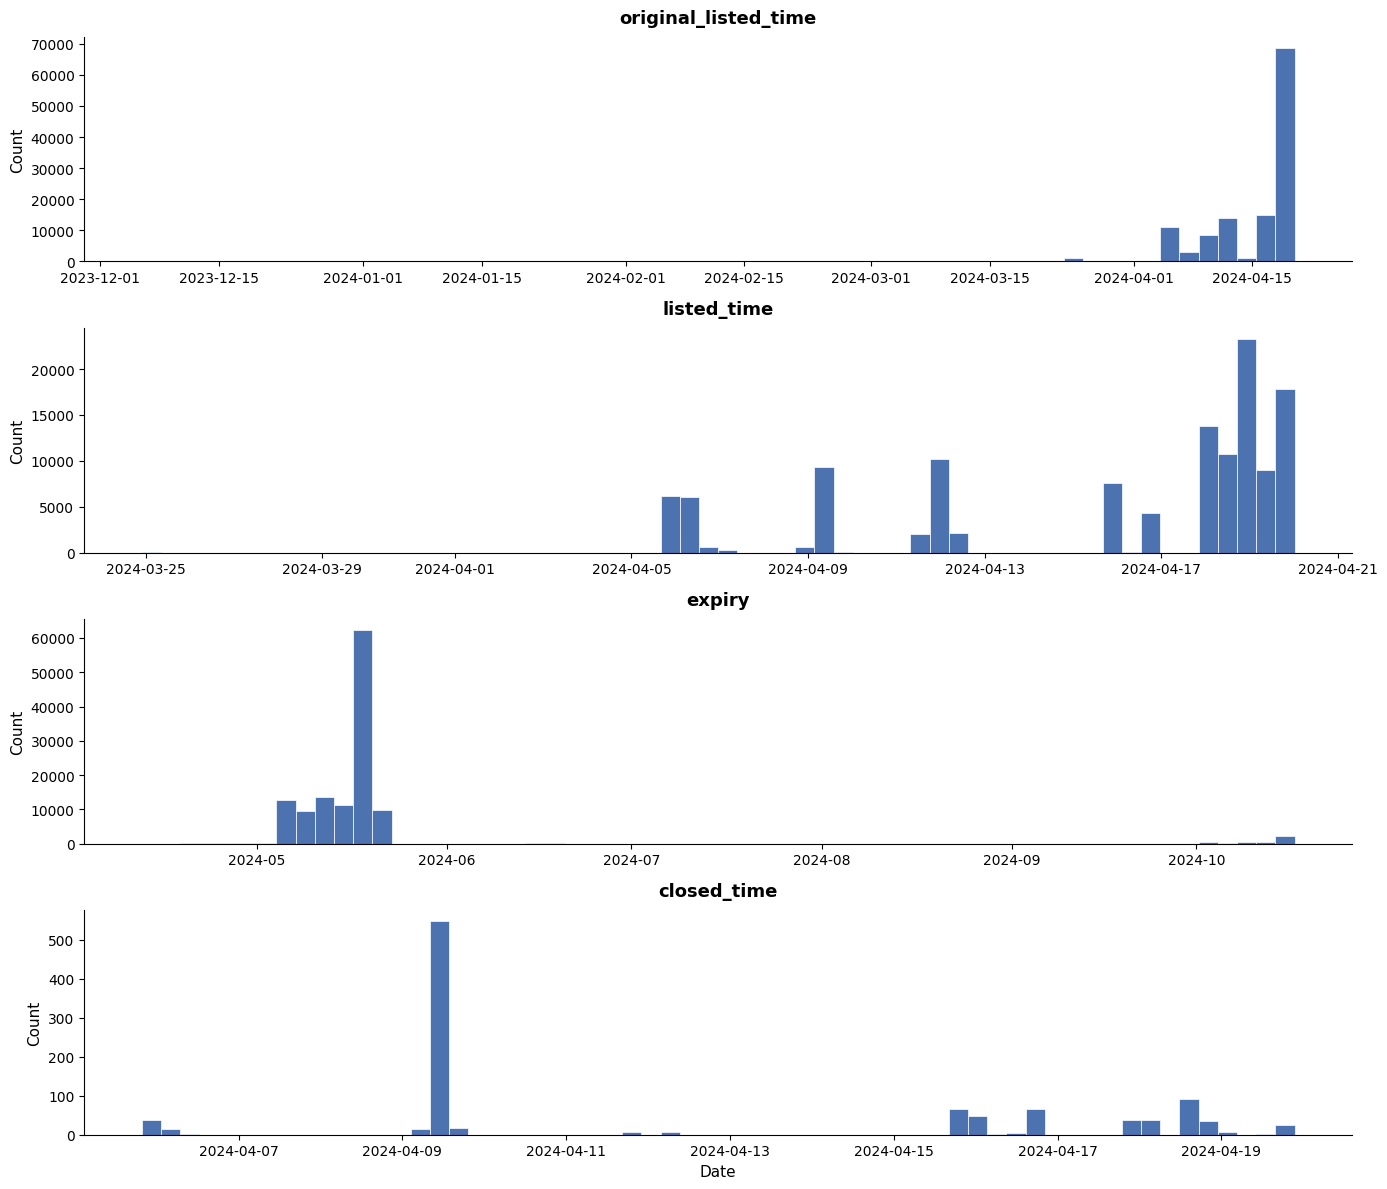

original_listed_time: 2023-12-05 → 2024-04-20  (span: 136 days)
listed_time: 2024-03-24 → 2024-04-20  (span: 26 days)
expiry: 2024-04-12 → 2024-10-17  (span: 187 days)
closed_time: 2024-04-05 → 2024-04-19  (span: 14 days)


In [22]:
time_cols = ['original_listed_time', 'listed_time', 'expiry', 'closed_time']
df_time = df[time_cols].apply(lambda c: pd.to_datetime(c, unit='ms'))

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)

for ax, col in zip(axes, time_cols):
    series = df_time[col].dropna()
    ax.hist(series, bins=60, color='#4C72B0', edgecolor='white', linewidth=0.5)
    ax.set_title(col, fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('Count', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_xlabel('Date', fontsize=11)
plt.tight_layout()
plt.show()

for col in time_cols:
    series = df_time[col].dropna()
    print(f"{col}: {series.min().date()} → {series.max().date()}  (span: {(series.max() - series.min()).days} days)")

### 7.2 Categorical Features

Low-cardinality categorical columns are shown together in a single figure. High-cardinality fields (`location`, `company_name`) are shown as top-N bar charts separately. Columns already flagged as constant or identifiers are excluded.

#### 7.2.1 Low-Cardinality Features

All categorical columns with ≤ 7 unique values plotted side-by-side: `formatted_work_type`, `formatted_experience_level`, `pay_period`, `application_type`, `currency`, `work_type`.

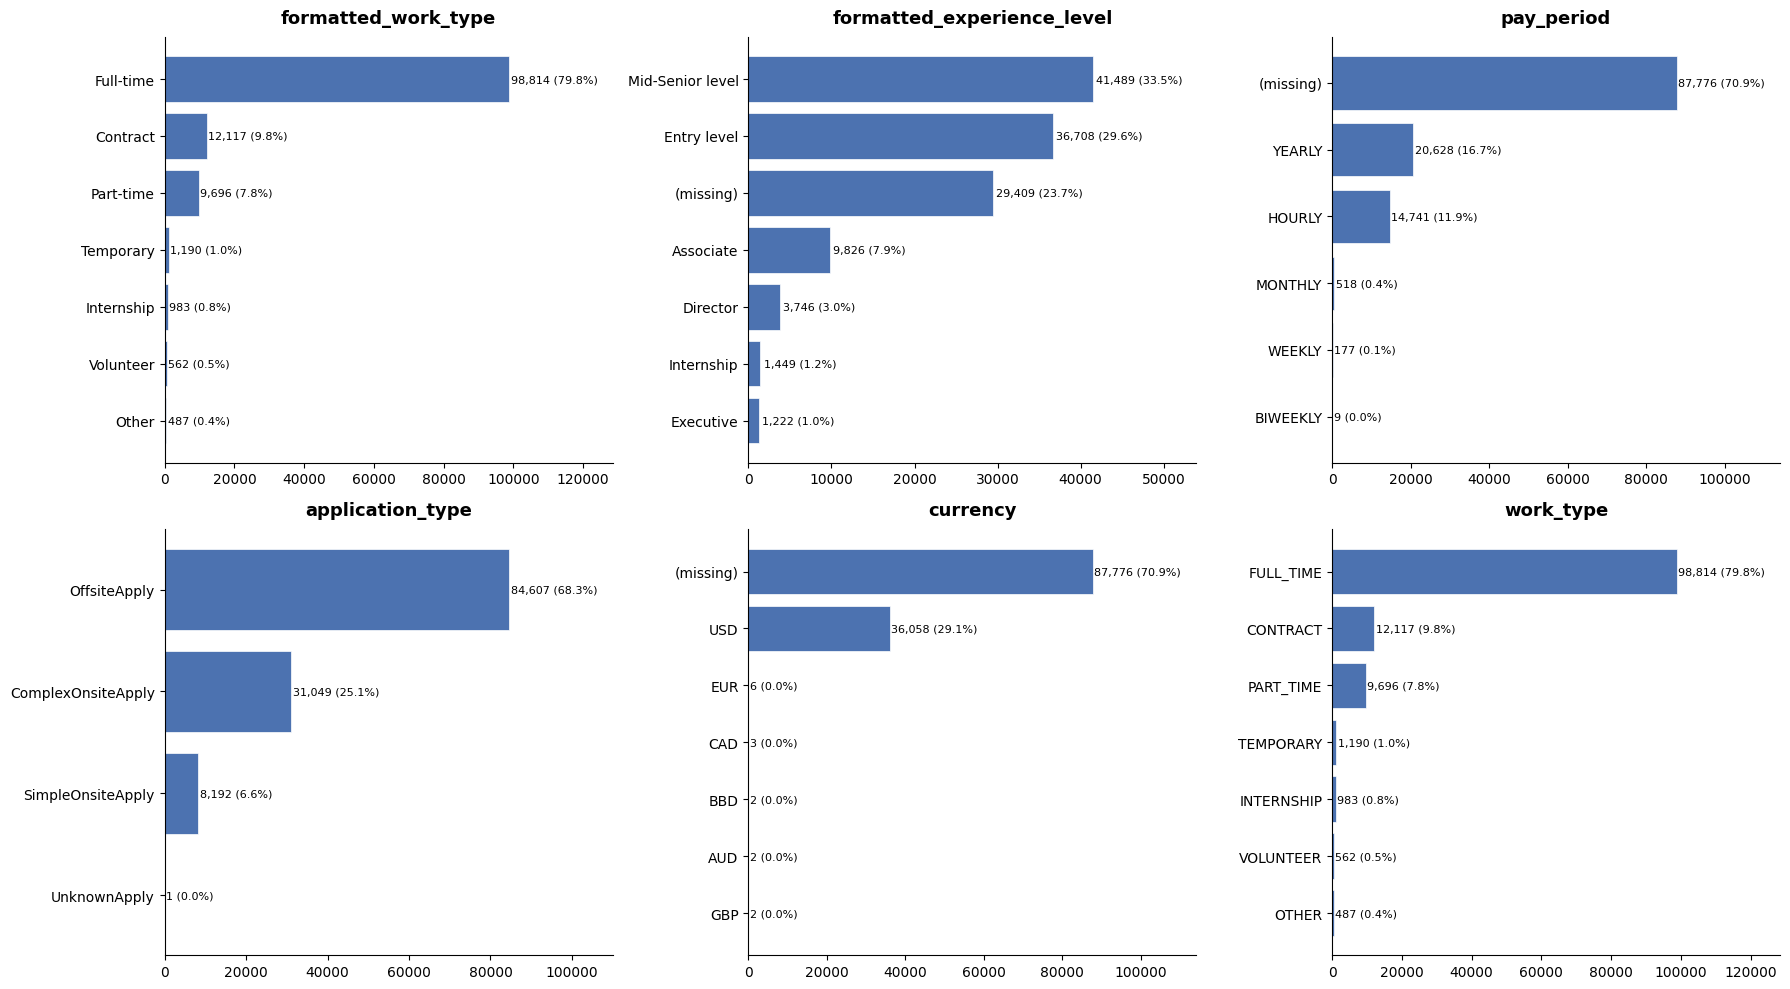

In [23]:
low_card_cols = [
    'formatted_work_type',
    'formatted_experience_level',
    'pay_period',
    'application_type',
    'currency',
    'work_type',
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, low_card_cols):
    counts = df[col].value_counts(dropna=False)
    # replace NaN label for readability
    counts.index = [str(i) if pd.notna(i) else '(missing)' for i in counts.index]

    bars = ax.barh(counts.index, counts.values, color='#4C72B0', edgecolor='white', linewidth=0.5)
    ax.set_title(col, fontsize=13, fontweight='bold', pad=10)
    ax.invert_yaxis()
    ax.spines[['top', 'right']].set_visible(False)

    # annotate counts + percentages
    total = len(df)
    for bar, val in zip(bars, counts.values):
        ax.text(val + total * 0.003, bar.get_y() + bar.get_height() / 2,
                f'{val:,} ({val/total*100:.1f}%)',
                va='center', fontsize=8)

    ax.set_xlim(0, counts.max() * 1.3)

plt.tight_layout()
plt.show()

- **Work type**: dominated by full-time; long tail (temporary, internship, volunteer, other) is negligible.
- **Experience level**: mid-senior + entry level lead; ~24% missing (likely undisclosed, not a quality issue).
- **Pay period** & **currency**: ~71% missing each - salary info rarely disclosed; USD dominates where present.
- **Application type**: ~68% offsite redirect, consistent with `applies` only tracked for onsite-apply postings.

#### 7.2.2 High-Cardinality Features — Top 20 (`location`, `company_name`)

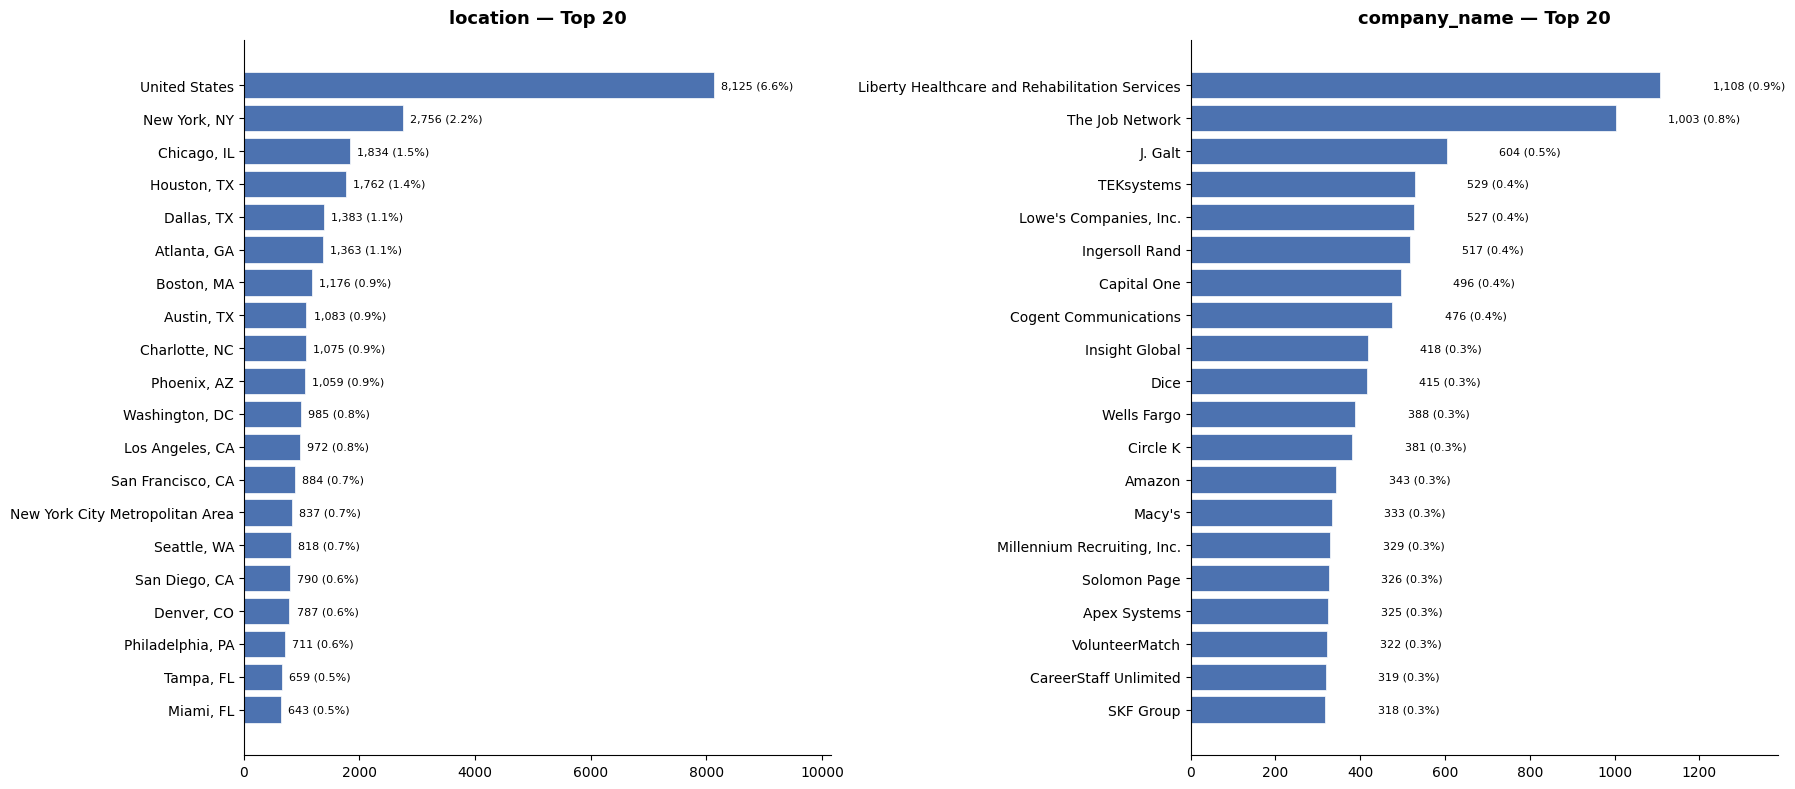

In [24]:
high_card_cols = ['location', 'company_name']

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, col in zip(axes, high_card_cols):
    top20 = df[col].value_counts().head(20)

    bars = ax.barh(top20.index, top20.values, color='#4C72B0', edgecolor='white', linewidth=0.5)
    ax.set_title(f'{col} — Top 20', fontsize=13, fontweight='bold', pad=12)
    ax.invert_yaxis()
    ax.spines[['top', 'right']].set_visible(False)

    total = len(df)
    for bar, val in zip(bars, top20.values):
        ax.text(val + total * 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:,} ({val/total*100:.1f}%)',
                va='center', fontsize=8)

    ax.set_xlim(0, top20.max() * 1.25)

plt.tight_layout()
plt.show()

- **Location**: highly fragmented; top entry is a generic "United States" catch-all, rest are individual cities in a long tail.
- **Company name**: even more dispersed — mix of staffing firms, large corporates, and niche employers.

### 7.3 Text Features

`title` and `description` are high-cardinality free-text fields (72k and 108k unique values respectively). Rather than plotting value counts, we look at length distributions and the most frequent titles to understand how standardized or noisy the text data is.

#### 7.3.1 Text Length Distributions (`title`, `description`)

Character and word counts reveal whether text fields are reasonably uniform or contain extreme outliers (e.g. one-word titles, copy-pasted mega-descriptions).

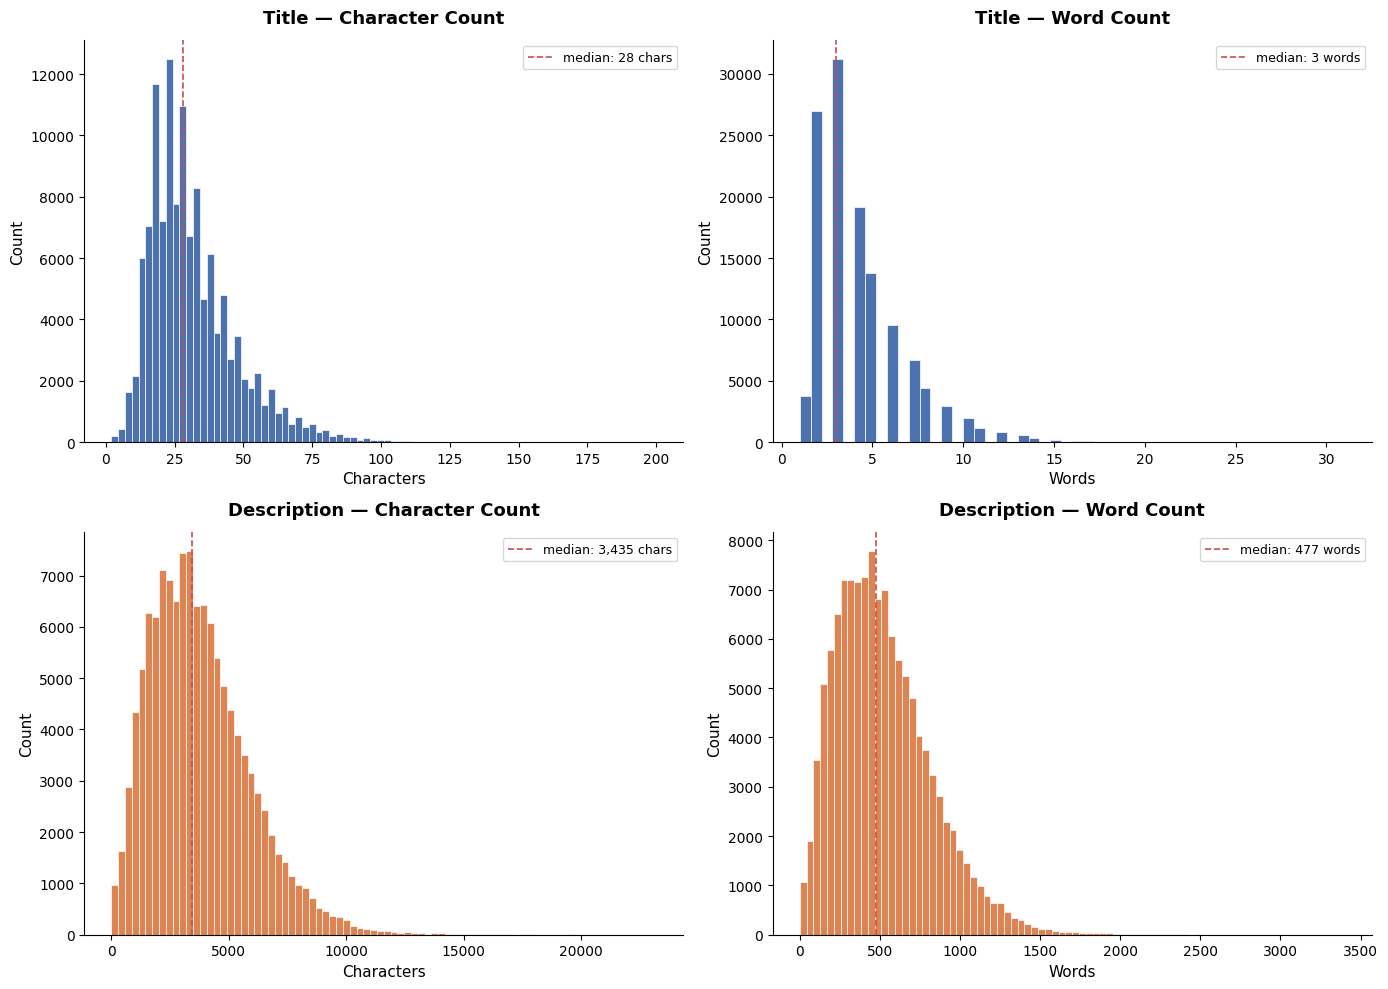

Title words — min: 1  |  median: 3  |  mean: 4.2  |  p99: 13  |  max: 31
Description words — min: 1  |  median: 477  |  mean: 523.1  |  p99: 1392  |  max: 3,400


In [25]:
df['title_len_chars'] = df['title'].str.len()
df['title_len_words'] = df['title'].str.split().str.len()
df['desc_len_chars'] = df['description'].str.len()
df['desc_len_words'] = df['description'].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- title: char length ---
axes[0, 0].hist(df['title_len_chars'].dropna(), bins=80, color='#4C72B0', edgecolor='white', linewidth=0.5)
axes[0, 0].axvline(df['title_len_chars'].median(), color='#C44E52', linestyle='--', linewidth=1.2,
                    label=f"median: {df['title_len_chars'].median():.0f} chars")
axes[0, 0].set_title('Title — Character Count', fontsize=13, fontweight='bold', pad=12)
axes[0, 0].set_xlabel('Characters', fontsize=11)
axes[0, 0].set_ylabel('Count', fontsize=11)
axes[0, 0].legend(fontsize=9)
axes[0, 0].spines[['top', 'right']].set_visible(False)

# --- title: word length ---
axes[0, 1].hist(df['title_len_words'].dropna(), bins=50, color='#4C72B0', edgecolor='white', linewidth=0.5)
axes[0, 1].axvline(df['title_len_words'].median(), color='#C44E52', linestyle='--', linewidth=1.2,
                    label=f"median: {df['title_len_words'].median():.0f} words")
axes[0, 1].set_title('Title — Word Count', fontsize=13, fontweight='bold', pad=12)
axes[0, 1].set_xlabel('Words', fontsize=11)
axes[0, 1].set_ylabel('Count', fontsize=11)
axes[0, 1].legend(fontsize=9)
axes[0, 1].spines[['top', 'right']].set_visible(False)

# --- description: char length ---
axes[1, 0].hist(df['desc_len_chars'].dropna(), bins=80, color='#DD8452', edgecolor='white', linewidth=0.5)
axes[1, 0].axvline(df['desc_len_chars'].median(), color='#C44E52', linestyle='--', linewidth=1.2,
                    label=f"median: {df['desc_len_chars'].median():,.0f} chars")
axes[1, 0].set_title('Description — Character Count', fontsize=13, fontweight='bold', pad=12)
axes[1, 0].set_xlabel('Characters', fontsize=11)
axes[1, 0].set_ylabel('Count', fontsize=11)
axes[1, 0].legend(fontsize=9)
axes[1, 0].spines[['top', 'right']].set_visible(False)

# --- description: word length ---
axes[1, 1].hist(df['desc_len_words'].dropna(), bins=80, color='#DD8452', edgecolor='white', linewidth=0.5)
axes[1, 1].axvline(df['desc_len_words'].median(), color='#C44E52', linestyle='--', linewidth=1.2,
                    label=f"median: {df['desc_len_words'].median():,.0f} words")
axes[1, 1].set_title('Description — Word Count', fontsize=13, fontweight='bold', pad=12)
axes[1, 1].set_xlabel('Words', fontsize=11)
axes[1, 1].set_ylabel('Count', fontsize=11)
axes[1, 1].legend(fontsize=9)
axes[1, 1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

for col, label in [('title_len_words', 'Title'), ('desc_len_words', 'Description')]:
    s = df[col].dropna()
    print(f"{label} words — min: {s.min():.0f}  |  median: {s.median():.0f}  |  mean: {s.mean():.1f}  |  p99: {s.quantile(0.99):.0f}  |  max: {s.max():,.0f}")

# clean up helper columns
df.drop(columns=['title_len_chars', 'title_len_words', 'desc_len_chars', 'desc_len_words'], inplace=True)

- **Title**: short and compact - median of 3 words / 28 chars; right-skewed but bounded, with even p99 at just 13 words.
- **Description**: substantially longer - median ~477 words / ~3.4K chars; right-skewed with a long tail reaching 3,400 words, but the bulk sits in a tight band. These are the primary free-text fields for any future NLP work.

#### 7.3.2 Most Frequent Job Titles — Top 25

A quick look at the most common titles to gauge how standardized role naming is and which industries dominate the dataset.

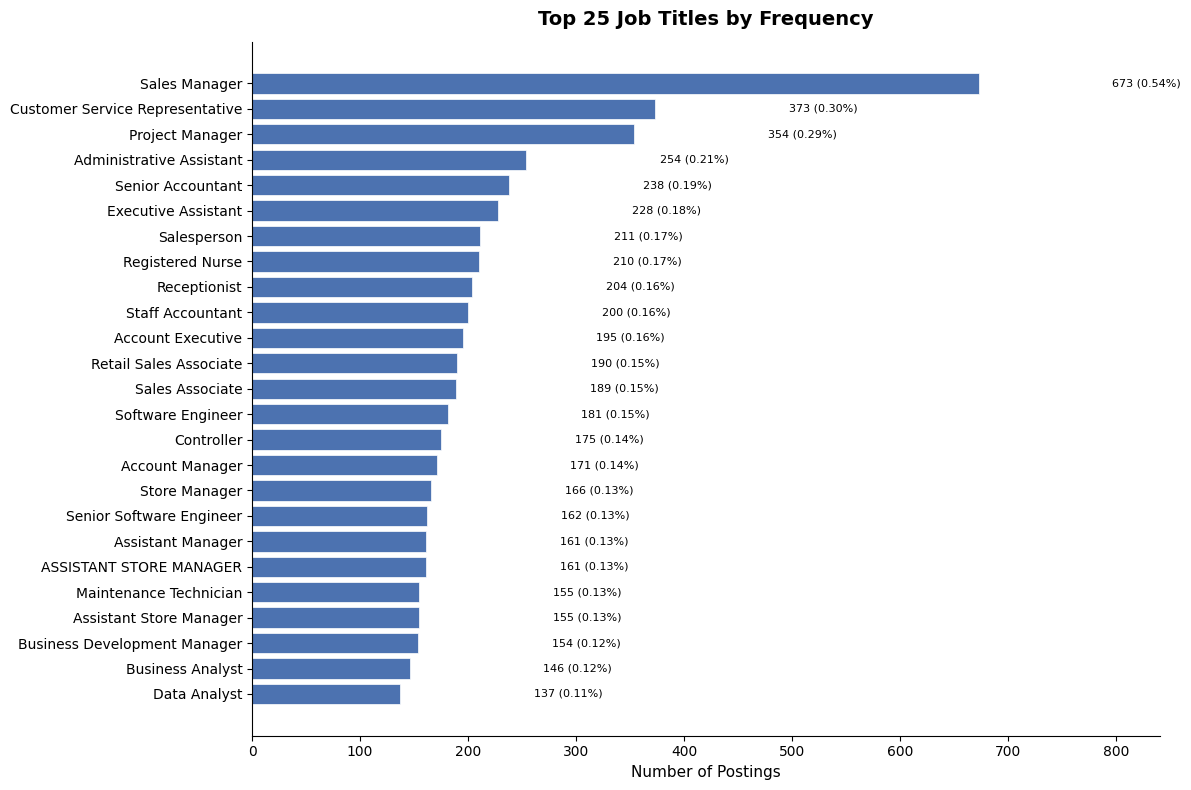

Unique titles: 72,521 out of 123,849 rows (58.6%)
Top 25 titles cover 5,443 postings (4.4% of dataset)


In [26]:
top25_titles = df['title'].value_counts().head(25)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(top25_titles.index, top25_titles.values, color='#4C72B0', edgecolor='white', linewidth=0.5)
ax.invert_yaxis()
ax.set_title('Top 25 Job Titles by Frequency', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Number of Postings', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

total = len(df)
for bar, val in zip(bars, top25_titles.values):
    ax.text(val + total * 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:,} ({val/total*100:.2f}%)',
            va='center', fontsize=8)

ax.set_xlim(0, top25_titles.max() * 1.25)
plt.tight_layout()
plt.show()

unique_titles = df['title'].nunique()
print(f"Unique titles: {unique_titles:,} out of {len(df):,} rows ({unique_titles/len(df)*100:.1f}%)")
print(f"Top 25 titles cover {top25_titles.sum():,} postings ({top25_titles.sum()/len(df)*100:.1f}% of dataset)")

- **Job title**: extremely high cardinality  ~59% of rows have a unique title and the top 25 cover only ~4%. Inconsistent casing/naming is visible even in the top 25 (e.g. "Assistant Manager" vs "ASSISTANT STORE MANAGER" vs "Assistant Store Manager") - would need normalization for any grouping analysis.

## 8. Correlations

### 8.1 Numeric Correlations

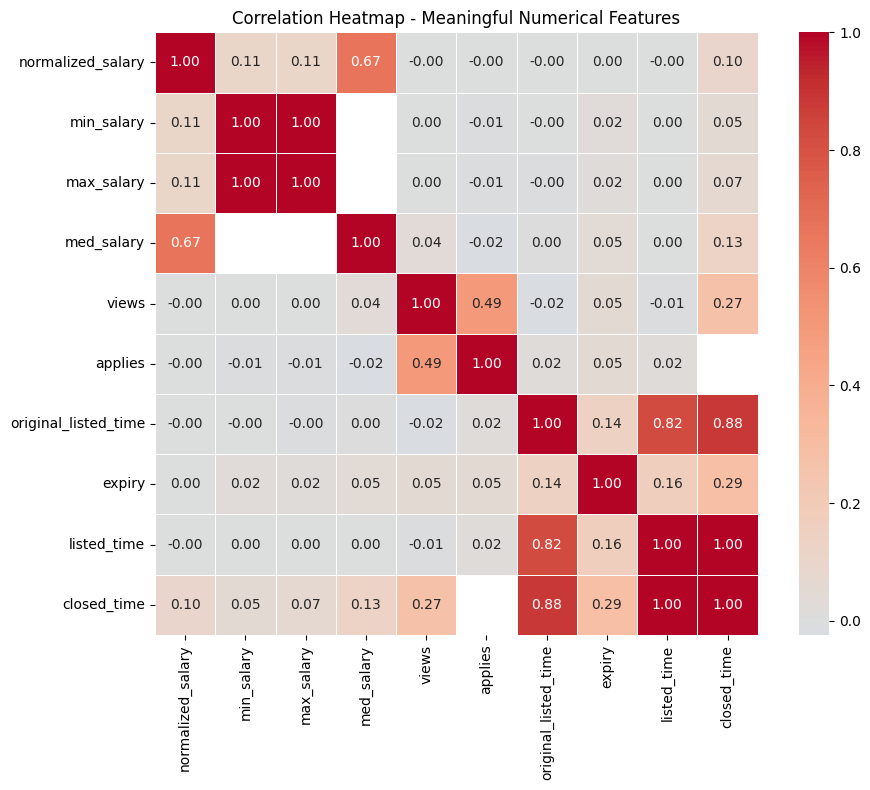

In [33]:
# Select only the meaningful numerical features for correlation
meaningful_features = ['normalized_salary', 'min_salary', 'max_salary', 'med_salary', 
                       'views', 'applies','original_listed_time', 'expiry', 'listed_time', 'closed_time']

# Filter dataframe to only include these features
df_corr = df[meaningful_features]

# Calculate correlation matrix
corr_matrix = df_corr.corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            fmt='.2f',
            linewidths=0.5)
plt.title('Correlation Heatmap - Meaningful Numerical Features')
plt.tight_layout()
plt.show()

**Observations:**

**Salary block:**
- `min_salary` and `max_salary` are perfectly correlated (r = 1.00), meaning they scale together in every posting that reports them. One of the two is redundant for modeling.
- `med_salary` correlates strongly with `normalized_salary` (r = 0.67), but its correlation with `min_salary` and `max_salary` cannot be computed (blank cells). This indicates these features rarely or never coexist in the same row, likely because they come from different compensation reporting formats.
- `normalized_salary` itself only weakly correlates with `min_salary` and `max_salary` (r = 0.11), suggesting that the normalization logic compresses or transforms the range in a way that decouples it from the raw bounds.

**Engagement block:**
- `views` and `applies` show a moderate positive correlation (r = 0.49). Beyond each other, neither correlates meaningfully with salary or time features (values near zero), confirming that engagement is largely independent of pay level and posting timing.
- The one exception is `views` and `closed_time` (r = 0.27), which makes intuitive sense: postings that stay open longer accumulate more views.

**Timestamp block:**
- `listed_time` and `closed_time` are perfectly correlated (r = 1.00), and both correlate strongly with `original_listed_time` (r = 0.82 and 0.88 respectively). This is expected since these timestamps track the same posting lifecycle.
- `expiry` stands apart with weaker correlations to the other timestamps (r = 0.14 to 0.29), suggesting expiry dates follow a different logic (e.g., fixed durations or employer-set deadlines) rather than simply tracking when the post was created.

**Blank cells:**
- Several pairs show empty cells rather than values (e.g., `med_salary` vs. `min/max_salary`, `closed_time` vs. `applies`). This means these feature pairs have too few overlapping non-null rows to compute a correlation, reinforcing the co-missingness patterns identified in Section 5.

**Overall:** Salary, engagement, and timestamps form three largely independent blocks with strong internal correlations but weak cross-block relationships. This suggests that knowing a posting's salary tells you very little about its engagement, and vice versa.

### 8.2 Categorical-Numeric Relationship

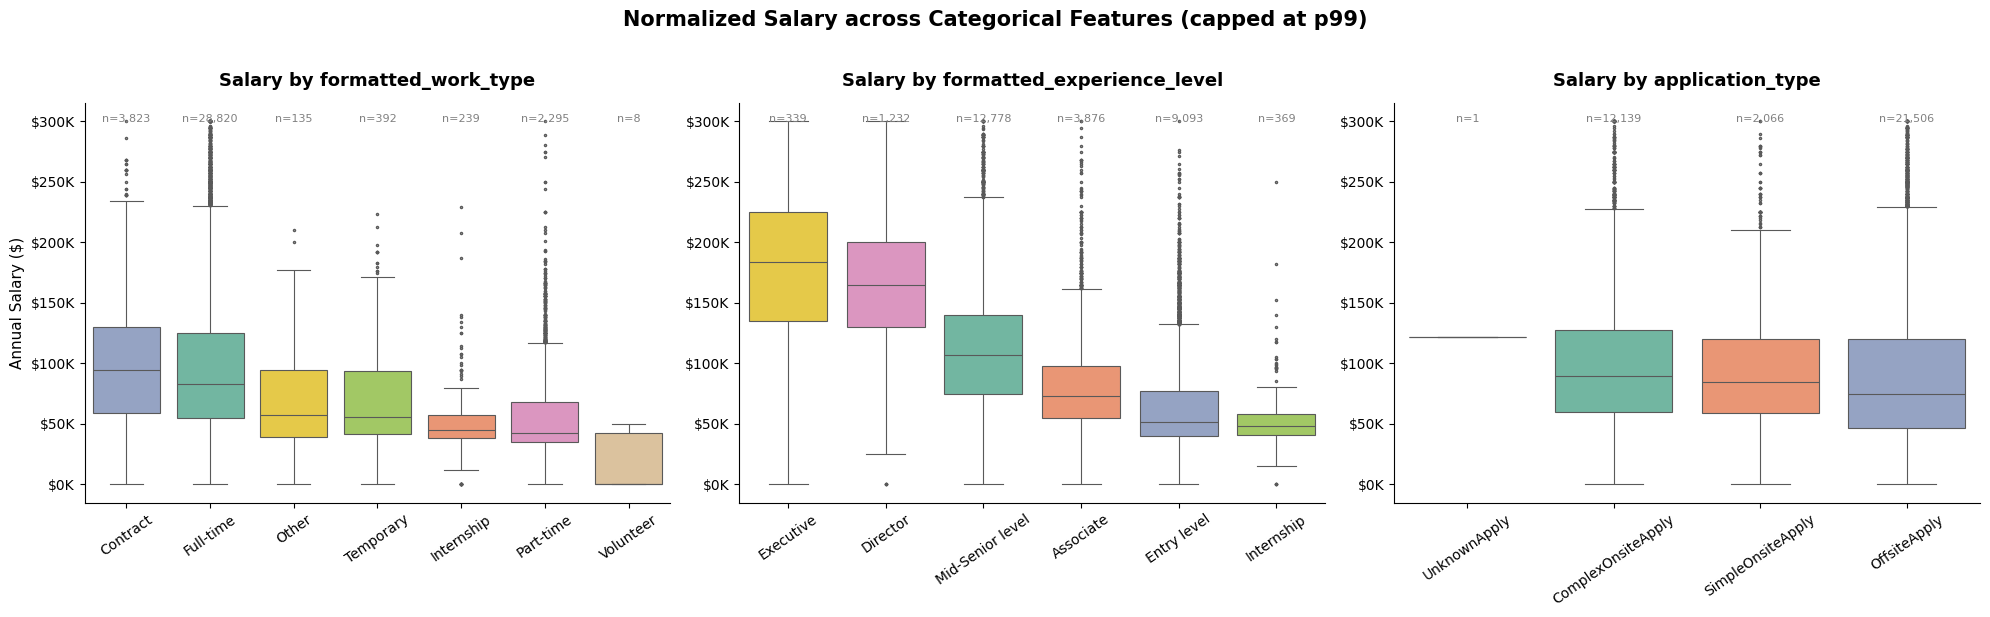

In [34]:

cat_cols  = ['formatted_work_type', 'formatted_experience_level', 'application_type']
num_col   = 'normalized_salary'
 
# cap at p99 for readability (same threshold used in section 7)
p99 = df[num_col].quantile(0.99)
plot_df = df[[num_col] + cat_cols].dropna(subset=[num_col]).copy()
plot_df = plot_df[plot_df[num_col] <= p99]
 
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
 
for ax, col in zip(axes, cat_cols):
    # order categories by median salary descending
    order = (plot_df.groupby(col)[num_col]
             .median()
             .sort_values(ascending=False)
             .index.tolist())
 
    sns.boxplot(
        data=plot_df, x=col, y=num_col, order=order,
        hue=col, palette='Set2', legend=False,
        fliersize=1.5, linewidth=0.8, ax=ax
    )
 
    ax.set_title(f'Salary by {col}', fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Annual Salary ($)' if ax == axes[0] else '', fontsize=11)
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K')
    )
    ax.tick_params(axis='x', rotation=35)
    ax.spines[['top', 'right']].set_visible(False)
 
    # annotate group sizes
    for i, cat in enumerate(order):
        n = (plot_df[col] == cat).sum()
        ax.text(i, ax.get_ylim()[1] * 0.97, f'n={n:,}',
                ha='center', va='top', fontsize=8, color='grey')
 
fig.suptitle('Normalized Salary across Categorical Features (capped at p99)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
 
 

**Observations:**

- **Work type**: Contract and full-time roles have the highest median salaries (~$90-100K), while internships, part-time, and volunteer positions cluster around $40-50K. The "Volunteer" category has only 8 observations, so its box is unreliable.
- **Experience level**: A clear salary ladder emerges from Internship (~$45K median) through Entry level, Associate, Mid-Senior, Director, up to Executive (~$190K median). The spread also widens at senior levels, suggesting more salary negotiation variability.
- **Application type**: Minimal differentiation across application types. "UnknownApply" has only 1 observation and should be ignored. The remaining three categories show nearly identical salary distributions.

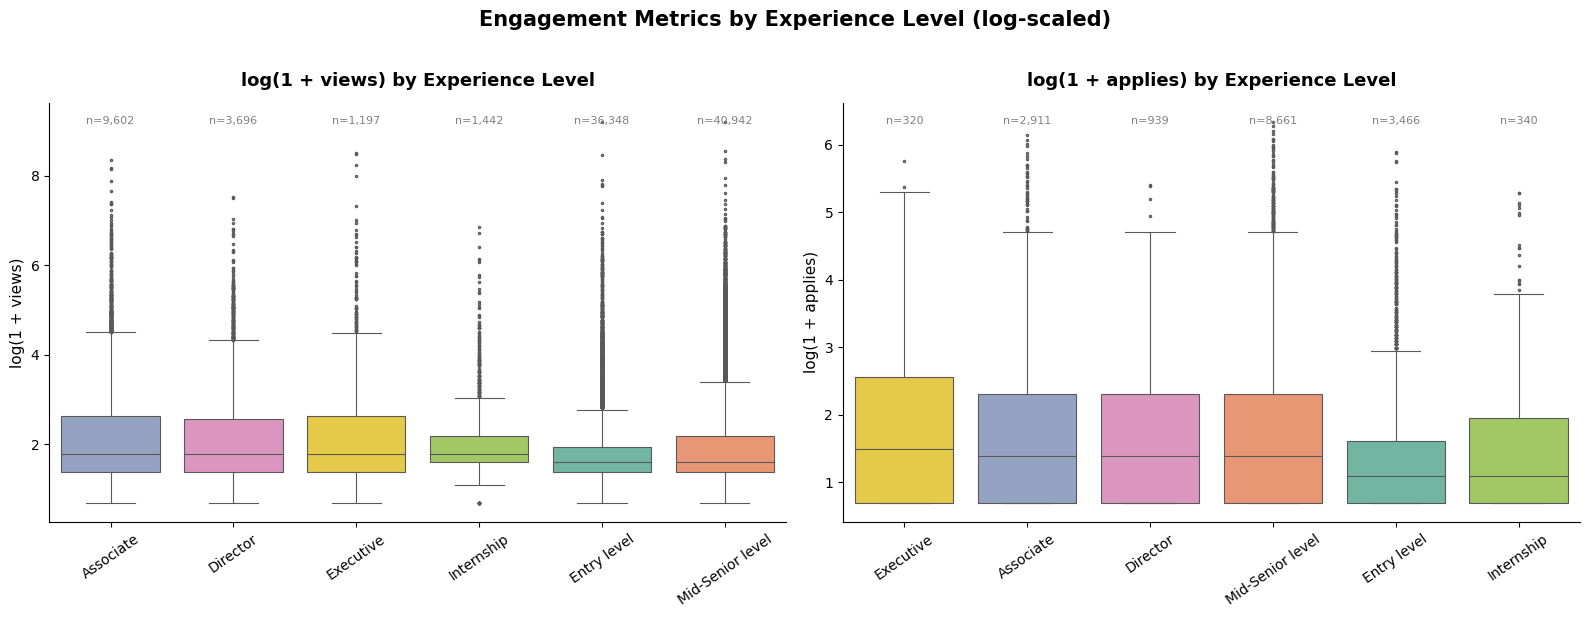

In [35]:

eng_cols = ['views', 'applies']
cat_col  = 'formatted_experience_level'
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
for ax, metric in zip(axes, eng_cols):
    sub = df[[metric, cat_col]].dropna()
 
    # log-transform to handle heavy skew (consistent with section 7)
    sub = sub.copy()
    sub[metric] = np.log1p(sub[metric])
 
    order = (sub.groupby(cat_col)[metric]
             .median()
             .sort_values(ascending=False)
             .index.tolist())
 
    sns.boxplot(
        data=sub, x=cat_col, y=metric, order=order,
        hue=cat_col, palette='Set2', legend=False,
        fliersize=1.5, linewidth=0.8, ax=ax
    )
 
    ax.set_title(f'log(1 + {metric}) by Experience Level',
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel(f'log(1 + {metric})', fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=35)
    ax.spines[['top', 'right']].set_visible(False)
 
    for i, cat in enumerate(order):
        n = (sub[cat_col] == cat).sum()
        ax.text(i, ax.get_ylim()[1] * 0.97, f'n={n:,}',
                ha='center', va='top', fontsize=8, color='grey')
 
fig.suptitle('Engagement Metrics by Experience Level (log-scaled)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
 
 

Engagement distributions are remarkably similar across experience levels after log-scaling - median `views` and `applies` differ only slightly between entry-level and executive postings. This suggests that posting visibility on the platform is driven more by recency, company brand, or algorithmic factors than by the seniority of the role.

### 8.3 Engegement Correlation

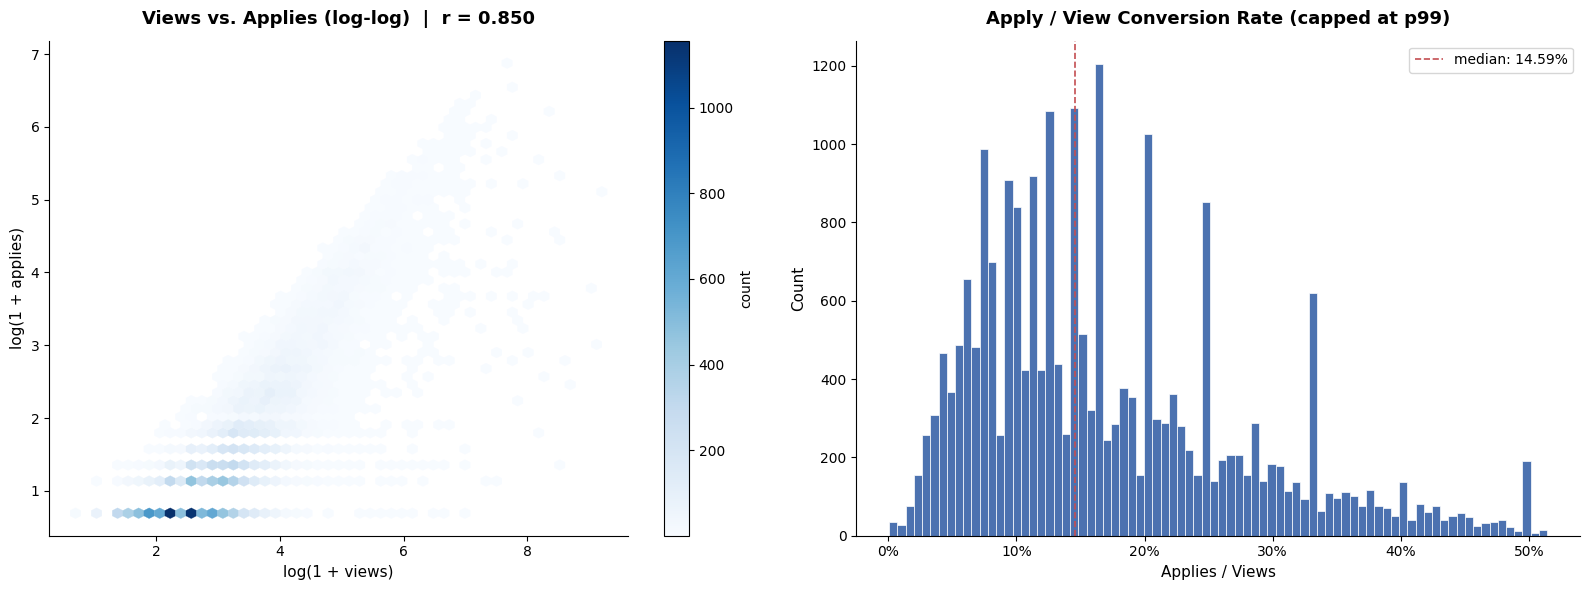

In [ ]:

eng = df[['views', 'applies']].dropna().copy()
eng['log_views']   = np.log1p(eng['views'])
eng['log_applies'] = np.log1p(eng['applies'])
 
r_val = eng['log_views'].corr(eng['log_applies'])
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# --- left: scatter with density coloring ---
ax = axes[0]
hb = ax.hexbin(
    eng['log_views'], eng['log_applies'],
    gridsize=50, cmap='Blues', mincnt=1, linewidths=0.2
)
ax.set_xlabel('log(1 + views)', fontsize=11)
ax.set_ylabel('log(1 + applies)', fontsize=11)
ax.set_title(f'Views vs. Applies (log-log)  |  r = {r_val:.3f}',
             fontsize=13, fontweight='bold', pad=12)
ax.spines[['top', 'right']].set_visible(False)
fig.colorbar(hb, ax=ax, label='count')
 
# --- right: conversion rate distribution ---
ax = axes[1]
# only where views > 0 to avoid division issues
valid = eng[eng['views'] > 0].copy()
valid['conversion'] = valid['applies'] / valid['views']
 
# cap at p99 for readability
cap = valid['conversion'].quantile(0.99)
valid_capped = valid[valid['conversion'] <= cap]
 
ax.hist(valid_capped['conversion'], bins=80, color='#4C72B0',
        edgecolor='white', linewidth=0.5)
ax.axvline(valid_capped['conversion'].median(), color='#C44E52',
           linestyle='--', linewidth=1.2,
           label=f"median: {valid_capped['conversion'].median():.2%}")
ax.set_title('Apply / View Conversion Rate (capped at p99)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Applies / Views', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=10)
 
plt.tight_layout()
plt.show()
 

**Observations:**

- **Log-log scatter**: Views and applies are strongly positively correlated (**r = 0.85**), confirming that postings attracting more eyeballs also collect proportionally more applications. The densest cluster sits in the low-engagement region, consistent with the right-skewed distributions.
- **Conversion rate**: The distribution is right-skewed with a median of **14.59%** and an unusual spike at the **50%** mark, likely caused by low-view postings where one or two applies push the ratio to exactly half.

## 9. Conclusion

This exploration of the LinkedIn job postings dataset (123,849 rows, 31 columns) revealed several key findings that will guide the next stages of cleaning and analysis.

**Data quality** is mixed. While there are no exact duplicate rows and core fields like `title`, `location`, and `job_posting_url` are fully populated, salary-related columns are missing in roughly 71-76% of rows, and the `applies` metric is only available for about 19% of postings (those using onsite/Easy Apply). These gaps are structural rather than random, reflecting optional fields and platform-level tracking differences, so imputation may not be appropriate for all of them.

**Duplication** operates on multiple levels. Beyond 52 content-identical rows, approximately 4,027 near-duplicates (~3.25%) emerge when time and engagement columns are excluded, likely representing reposted listings. At the broadest level, over 17,000 rows belong to same-position clusters (matching title, company, and description), capturing both reposts and multi-city postings for a single role.

**Distributions** are heavily right-skewed across most numeric features. Salary has extreme outliers (up to $535.6M, clearly data entry errors) but a reasonable core distribution (median ~$81.5K). Engagement metrics are concentrated at very low values (median 4 views, median 3 applies), with a long tail of high-visibility postings. Categorical features are dominated by full-time roles and mid-senior/entry-level positions, while `title` and `location` are highly fragmented.

**Correlations** confirmed that `min_salary` and `max_salary` are perfectly correlated (r = 1.00), making one redundant. Views and applies are strongly linked (r = 0.49), though engagement levels are largely uniform across experience levels, suggesting platform or algorithmic factors drive visibility more than role seniority.

**Recommended next steps** for the cleaning phase include: removing or capping salary outliers, dropping zero-variance and redundant columns (`sponsored`, `remote_allowed`, `compensation_type`, and one of `min_salary`/`max_salary`), defining a deduplication strategy for reposts, converting epoch timestamps to datetime, and normalizing job titles for grouping analysis.